In [1]:
# auto reload modules
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from cns.data_utils import load_all_samples, save_cns_fig, load_merged_samples
from cns.utils.kneepoint import find_knee, count_cum_val

In [3]:
plt.rcParams.update({'font.size': 12, 'figure.figsize': (6, 6), 'figure.dpi': 100})	

In [4]:
data = load_all_samples(False, False, True)
# rename key TCGA_hg19 to TCGA
data["TCGA"] = data["TCGA_hg19"]
del data["TCGA_hg19"]
data["combined"] = load_merged_samples(False, False, False)
datasets = list(data.keys())
print(datasets)
colors = {"PCAWG": "C0", "TCGA": "C1", "TRACERx": "C2", "combined": "gray"}

['PCAWG', 'TRACERx', 'TCGA', 'combined']


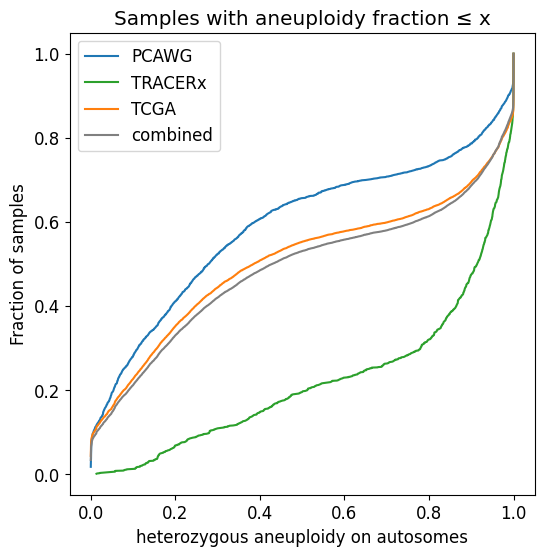

In [5]:
feature = "ane_het_aut"   
for k in datasets:
    X, Y = count_cum_val(data[k][feature])    
    plt.plot(X, Y, label=k, color=colors[k])    
    
plt.xlabel("heterozygous aneuploidy on autosomes")
plt.ylabel("Fraction of samples")
plt.legend()
plt.title(f"Samples with aneuploidy fraction ≤ x")
save_cns_fig(fig_name=f"fig_samples_imbalance_fraction")

PCAWG filtered 211
TCGA filtered 745
combined filtered 965


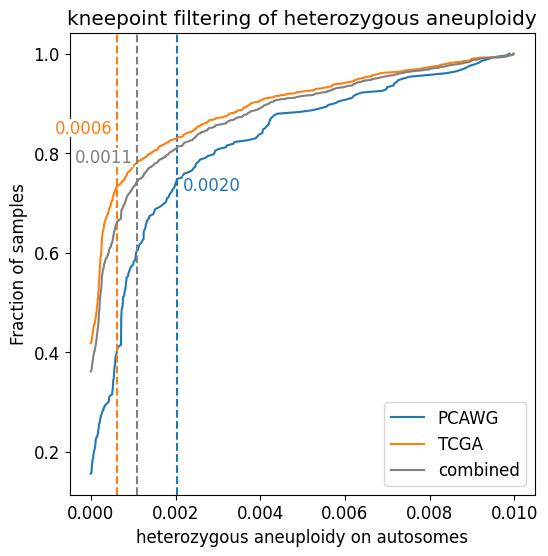

In [17]:
feature = "ane_het_aut"
offsets = {"PCAWG": (0.0015, -0.03), "TCGA": (-0.0001, 0.1), "TRACERx": (+0.0000, 0.01), "combined": (-0.0001, 0.03)}
for k in datasets:
    X, Y = count_cum_val(data[k][feature], max_val=0.01)
    knee_index, knee_value = find_knee(X, Y, knee=True)
    if knee_index < 0:
        continue
    plt.plot(X, Y, label=k, color=colors[k])
    print(k, "filtered", sum(data[k][feature] <= X[knee_index]))
    x_pos = X[knee_index]
    plt.axvline(x_pos, color=colors[k], linestyle="--")
    plt.text(
        x_pos + offsets[k][0],
        Y[knee_index] + offsets[k][1],
        f"{x_pos:.4f}",
        color=colors[k],
        verticalalignment="bottom",
        horizontalalignment="right",
        bbox=dict(facecolor="white", edgecolor="none", pad=0.3),
    )

plt.xlabel("heterozygous aneuploidy on autosomes")
plt.ylabel("Fraction of samples")
plt.title(f"kneepoint filtering of heterozygous aneuploidy")
plt.legend()
save_cns_fig(fig_name=f"fig_samples_imbalance_fraction")

PCAWG filtered 28
PCAWG below [('SP107557', 0.5766912308706281)]
TRACERx filtered 89
TCGA filtered 269
combined filtered 1927
combined below [('SP107557', 0.5766912308706281)]


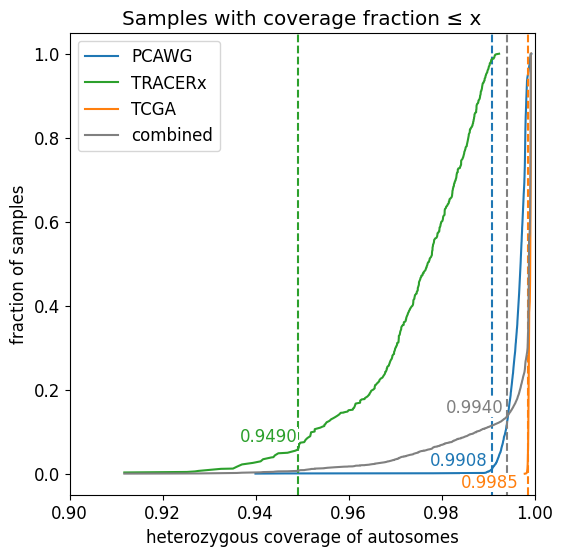

In [7]:
feature = "cover_het_aut"   
min_val = 0.90
offsets = { "PCAWG": (-0.001, 0.000), "TCGA": (-0.002, -0.07), "TRACERx": (+0.0000, 0.01), "combined": (-0.00075, 0.0)}	
for k in datasets:
    X, Y = count_cum_val(data[k][feature], min_val=min_val)
    below = data[k][feature][data[k][feature] < min_val]

    knee_index, knee_value = find_knee(X, Y, knee=False)
    if knee_index < 0:
        continue
    print(k, "filtered", sum(data[k][feature] <= X[knee_index]))
    x_pos = X[knee_index]
    plt.axvline(x_pos, color=colors[k], linestyle="--")
    plt.text(
        x_pos + offsets[k][0], 
        Y[knee_index] + offsets[k][1], 
        f"{x_pos:.4f}", 
        color=colors[k], 
        verticalalignment='bottom', 
        horizontalalignment='right',
        bbox=dict(facecolor='white', edgecolor='none', pad=.3)
    )

    if (len(below) > 0):
        print(k, "below", list(zip(below.index.values, below.values)))
    plt.plot(X, Y, label=k, color=colors[k])    

plt.xlim(min_val, 1)
plt.xlabel("heterozygous coverage of autosomes")
plt.ylabel("fraction of samples")
plt.legend()
plt.title(f"Samples with coverage fraction ≤ x")
save_cns_fig(f"fig_samples_coverage_fraction_knee")

PCAWG fitered 3
TRACERx fitered 19
TCGA fitered 16
combined fitered 352


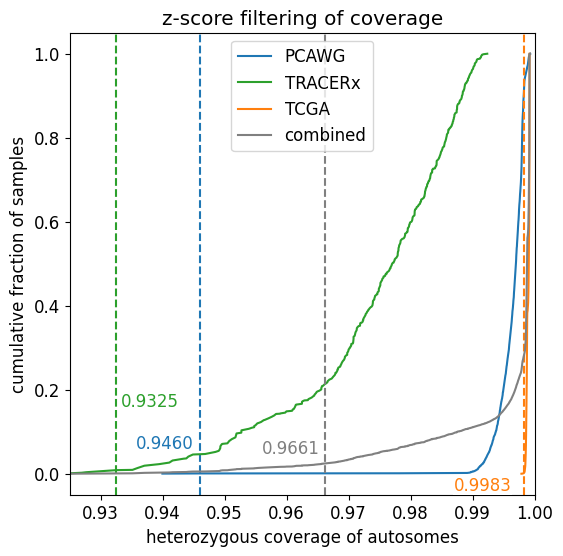

In [8]:
feature = "cover_het_aut"   
min_val = 0.925
outliers = {}
offsets = { "PCAWG": (-0.001, 0.05), "TCGA": (-0.002, -0.05), "TRACERx": (+0.01, 0.15), "combined": (-0.00075, 0.04)}	
for k in datasets:
    X, Y = count_cum_val(data[k][feature], min_val=min_val)
    plt.plot(X, Y, label=k, color=colors[k])   
    selection = data[k][feature]
    # calculate the z-score for selection
    z = (selection - selection.mean()) / selection.std()
    filter = z[(z < -3)]
    outliers[k] = data[k].loc[filter.index]
    print(k, "fitered", len(outliers[k]))
    x_pos = outliers[k][feature].max()
    plt.axvline(x_pos, color=colors[k], linestyle="--")
    plt.text(
        x_pos + offsets[k][0], 
        offsets[k][1], 
        f"{x_pos:.4f}", 
        color=colors[k], 
        verticalalignment='bottom', 
        horizontalalignment='right',
        bbox=dict(facecolor='white', edgecolor='none', pad=.3)
    )

plt.xlim(min_val, 1)
plt.xlabel("heterozygous coverage of autosomes")
plt.ylabel("cumulative fraction of samples")
plt.legend()
plt.title(f"z-score filtering of coverage")
save_cns_fig(f"fig_samples_coverage_fraction_zscore")

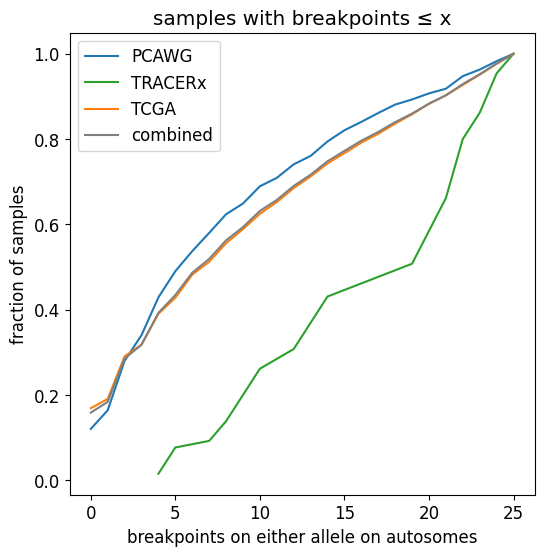

In [9]:
feature = "breaks_total_cn_aut"   
for k in datasets:
    X, Y = count_cum_val(data[k][feature], max_val=25)
    plt.plot(X, Y, label=k, color=colors[k])    

plt.ylabel("fraction of samples")
plt.xlabel("breakpoints on either allele on autosomes")
plt.title(f"samples with breakpoints ≤ x")
plt.legend()
save_cns_fig(f"fig_samples_breakpoints")

In [10]:
def plot_feature(feature, label, data, min_val=None, max_val=None):
    min_val = np.min([np.min(v[feature]) for v in data.values()]) if min_val is None else min_val
    max_val = np.max([np.max(v[feature]) for v in data.values()]) if max_val is None else max_val
    for k, v in data.items():
        X, Y = count_cum_val(v[feature], min_val, max_val)    
        plt.plot(X, Y, label=k, color=colors[k])    
        
    plt.xlabel(f"{label} value")
    plt.ylabel("fraction of samples")
    plt.legend()
    plt.title(f"samples with {label} fraction ≤ x")    
    save_cns_fig(f"fig_samples_{feature}")

Text(0.5, 18.825000000000003, 'total number of breakpoints')

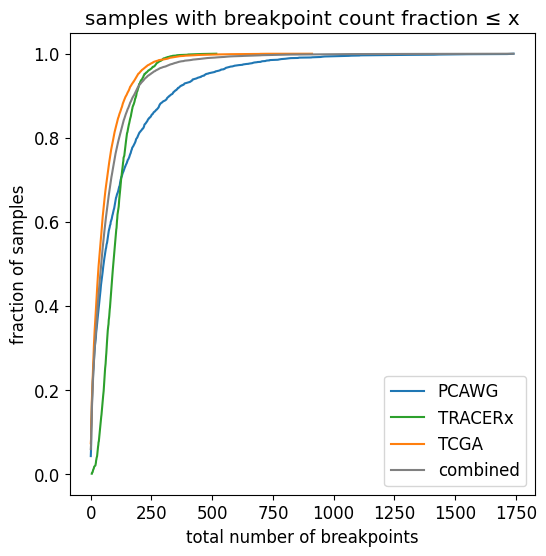

In [11]:
plot_feature("breaks_total_cn_aut", "breakpoint count", data)
plt.xlabel("total number of breakpoints")

Text(0.5, 18.825000000000003, 'heterozygous LOH on autosomes')

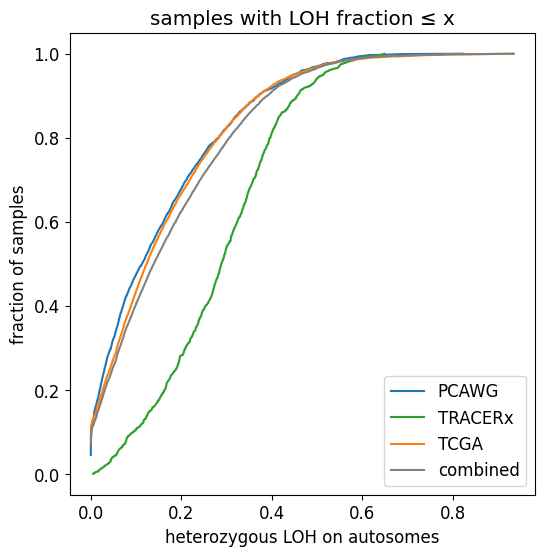

In [12]:
plot_feature("loh_het_aut", "LOH", data)
plt.xlabel("heterozygous LOH on autosomes")

Text(0.5, 18.825000000000003, 'average step between breakpoints on autosomes')

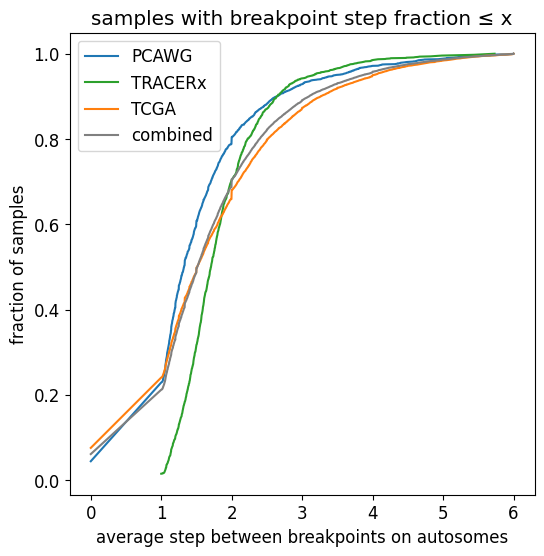

In [13]:
plot_feature("step_total_cn_aut", "breakpoint step", data, max_val = 6)
plt.xlabel("average step between breakpoints on autosomes")

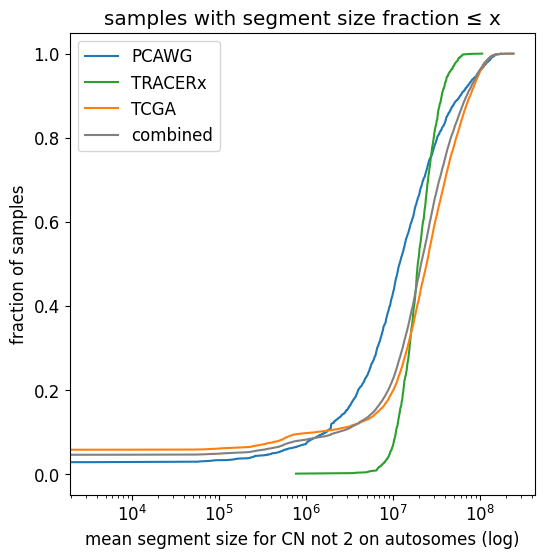

In [14]:
plot_feature("segsize_total_cn_aut", "segment size", data)
plt.xlabel("mean segment size for CN not 2 on autosomes (log)")
plt.xscale("log")